<a href="https://colab.research.google.com/github/RishikaBhawsingka/VOIS/blob/main/VOIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()


Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset.csv


In [3]:
import pandas as pd

# Step 1: Read the uploaded CSV
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")   # replace with actual filename

# Step 2: Get number of rows and columns
print("Rows, Columns:", df.shape)

# Step 3: Dataset info (column names, non-null counts, dtypes)
df.info()

# Step 4: Preview first 5 rows
df.head()


Rows, Columns: (4000, 28)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha        

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


Q1. What factors most strongly influence farm profitability?

Q2. Can farmers reduce water usage without significantly reducing yield?

Q3. Which Crop + Season + Irrigation combinations provide the best balance of yield, profit and water efficiency?

Q4. How do environmental conditions and soil characteristics affect crop productivity?

Q5. Can we identify high-risk farms that have low profitability, high water consumption and high disease/pest risk?

In [4]:
# Check missing values
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [10]:
df['Farm_ID'].duplicated().sum()
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [11]:
df.describe(include='object').T

,count,unique,top,freq
Farm_ID,4000,4000,SF13984,1
State,4000,8,Andhra Pradesh,529
District,4000,10,Ludhiana,427
Crop,4000,8,Rice,690
Season,4000,3,Kharif,1779
Irrigation_Method,4000,4,Flood,1310


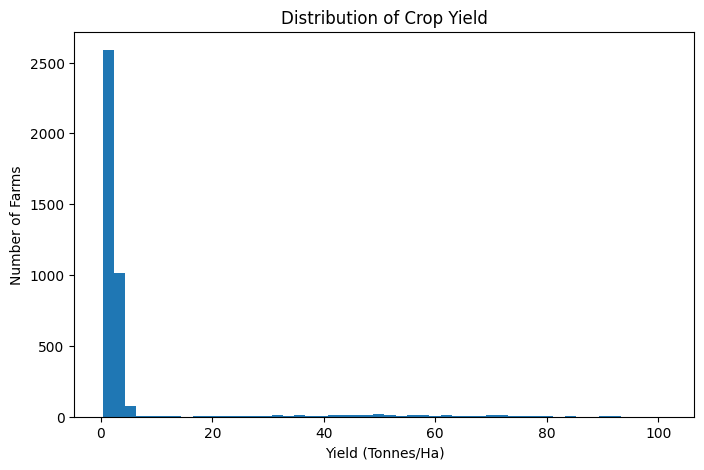

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['Yield_Tonnes_Ha'].dropna(), bins=50)
plt.xlabel('Yield (Tonnes/Ha)')
plt.ylabel('Number of Farms')
plt.title('Distribution of Crop Yield')
plt.show()
#yield

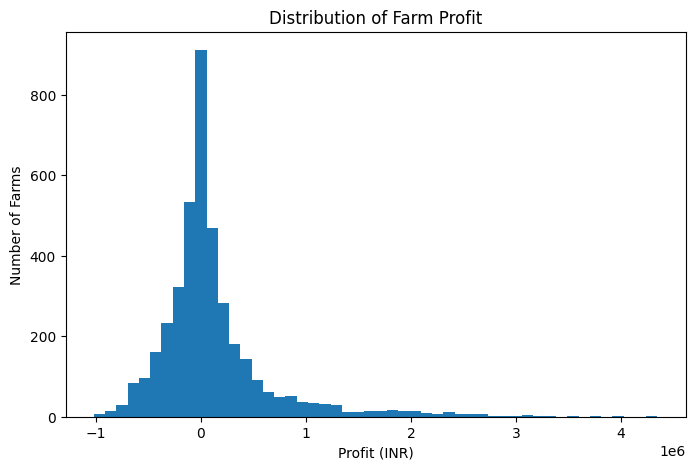

In [13]:
#profit
plt.figure(figsize=(8,5))
plt.hist(df['Profit_INR'], bins=50)
plt.xlabel('Profit (INR)')
plt.ylabel('Number of Farms')
plt.title('Distribution of Farm Profit')
plt.show()

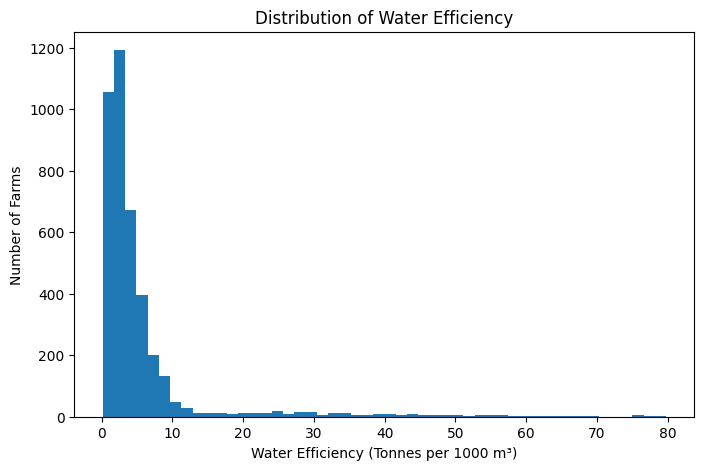

In [14]:
plt.figure(figsize=(8,5))
plt.hist(df['Water_Efficiency_t_per_1000m3'], bins=50)
plt.xlabel('Water Efficiency (Tonnes per 1000 m³)')
plt.ylabel('Number of Farms')
plt.title('Distribution of Water Efficiency')
plt.show()

In [15]:
df.nlargest(10, 'Yield_Tonnes_Ha')[
    ['State', 'District', 'Crop', 'Season',
     'Yield_Tonnes_Ha', 'Production_Tonnes',
     'Water_Used_m3', 'Profit_INR']
]

,State,District,Crop,Season,Yield_Tonnes_Ha,Production_Tonnes,Water_Used_m3,Profit_INR
1715,Gujarat,Indore,Sugarcane,Kharif,101.44,641.10,11781,1608291
3423,Andhra Pradesh,Indore,Sugarcane,Kharif,95.79,1424.40,23289,3330582
3525,Andhra Pradesh,Erode,Sugarcane,Rabi,93.13,648.18,10705,1471529
1464,Gujarat,Nashik,Sugarcane,Kharif,91.98,703.65,12787,2216708
3523,Karnataka,Nashik,Sugarcane,Kharif,91.46,75.00,1944,234320
2782,Gujarat,Nalgonda,Sugarcane,Rabi,91.32,522.35,12199,1236801
644,Andhra Pradesh,Ludhiana,Sugarcane,Kharif,89.34,668.26,11547,1984818
2847,Telangana,Warangal,Sugarcane,Kharif,87.76,672.24,12526,2041678
357,Punjab,Warangal,Sugarcane,Rabi,84.75,1249.21,23936,3378879
1178,Karnataka,Nalgonda,Sugarcane,Kharif,83.79,534.58,11086,1200815


In [16]:
crop_analysis = df.groupby('Crop').agg(
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Median_Yield=('Yield_Tonnes_Ha', 'median'),
    Avg_Profit=('Profit_INR', 'mean'),
    Median_Profit=('Profit_INR', 'median'),
    Avg_Water_Used=('Water_Used_m3', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Avg_Disease_Risk=('Disease_Pest_Risk_pct', 'mean'),
    Farms=('Farm_ID', 'count')
).sort_values('Avg_Profit', ascending=False)

crop_analysis

,Avg_Yield,Median_Yield,Avg_Profit,Median_Profit,Avg_Water_Used,Avg_Water_Efficiency,Avg_Disease_Risk,Farms
Crop,,,,,,,,
Sugarcane,46.938746,48.030,817187.986885,691166.0,13897.704918,30.477672,45.403934,305
Chilli,1.540344,1.560,750878.342233,536375.0,4577.468447,2.947709,46.062136,412
Cotton,1.225734,1.240,124546.915354,62092.5,5410.858268,1.938016,45.974606,508
Groundnut,1.317924,1.400,44858.120283,36307.0,3459.535377,3.154795,46.289151,424
Pulses,0.918198,0.940,-4238.052419,2575.5,2833.665323,2.896504,46.570161,496
Maize,2.717130,2.850,-83978.326679,-42625.0,4377.776770,5.602995,45.539564,551
Rice,2.439413,2.460,-102213.504348,-58286.0,10920.215942,1.946112,46.495797,690
Wheat,2.109216,2.225,-123398.337134,-76269.0,4054.402280,4.628393,47.854723,614


## 🌾 Question 1: Which crops are the most profitable, and how do profitability and water usage compare?

### Analysis

We grouped the farms by **Crop** and calculated the average and median yield, profit, water consumption, water efficiency, and disease/pest risk.

### Key Findings

* **Sugarcane** has the highest average profit at approximately **₹8.17 lakh per farm**, along with the highest average yield (**46.94 tonnes/ha**).
* However, Sugarcane is also the **most water-intensive crop**, using approximately **13,898 m³ of water per farm** on average.
* **Chilli** is particularly interesting: it generates an average profit of approximately **₹7.51 lakh**, almost comparable to Sugarcane, while using only **4,577 m³ of water** on average.
* **Cotton** is moderately profitable, with an average profit of approximately **₹1.25 lakh**.
* **Groundnut** generates a smaller positive average profit of approximately **₹44,858**.
* **Pulses** are close to break-even, with an average profit of approximately **-₹4,238**.
* **Maize, Rice, and Wheat** are loss-making on average, with Wheat showing the lowest average profit at approximately **-₹1.23 lakh**.
* Rice is particularly concerning because it combines **high water consumption (~10,920 m³)** with an average loss of approximately **₹1.02 lakh**.

### 💡 Key Insight

> **Higher profitability does not necessarily require proportionally higher water consumption.**

Sugarcane generates the highest average profit, but it consumes substantially more water. **Chilli achieves nearly comparable profitability while using roughly one-third as much water**, making it a potentially more water-efficient economic option.

### ⚠️ Important Observation

The very large difference between mean and median values, particularly for profit and yield, suggests that some crops may contain **extreme values/outliers**. Therefore, median profitability should also be considered before making final recommendations.

### 🎯 Analytical Direction

The next analysis should determine:

> **Which crop generates the highest profit for every 1,000 m³ of water consumed?**

This will help identify crops that provide the best **economic return relative to water usage**, rather than simply ranking crops by total profit.


Question 2: Which crop provides the highest profit relative to water consumed?

In [17]:
crop_analysis['Profit_per_1000m3'] = (
    crop_analysis['Avg_Profit'] /
    crop_analysis['Avg_Water_Used']
) * 1000

crop_analysis[
    ['Avg_Profit', 'Avg_Water_Used', 'Profit_per_1000m3']
].sort_values(
    'Profit_per_1000m3',
    ascending=False
)

,Avg_Profit,Avg_Water_Used,Profit_per_1000m3
Crop,,,
Chilli,750878.342233,4577.468447,164037.906758
Sugarcane,817187.986885,13897.704918,58800.211381
Cotton,124546.915354,5410.858268,23017.959294
Groundnut,44858.120283,3459.535377,12966.515844
Pulses,-4238.052419,2833.665323,-1495.607962
Rice,-102213.504348,10920.215942,-9360.025927
Maize,-83978.326679,4377.776770,-19182.870918
Wheat,-123398.337134,4054.402280,-30435.642200


## 💧 Question 2: Which crop provides the highest profit relative to water consumed?

### Analysis

To compare the economic value of water usage across crops, we calculated:

**Profit per 1,000 m³ of water = (Average Profit / Average Water Used) × 1,000**

### Key Findings

* **Chilli is the most water-efficient crop economically**, generating approximately **₹1.64 lakh profit per 1,000 m³ of water**.
* **Sugarcane**, despite having the highest average profit (**₹8.17 lakh**), generates only about **₹58,800 per 1,000 m³ of water** because of its very high water consumption.
* **Cotton** generates approximately **₹23,018 per 1,000 m³**, followed by Groundnut at approximately **₹12,967**.
* **Pulses, Rice, Maize, and Wheat** have negative values, indicating that their average profitability does not justify their corresponding water consumption in this dataset.
* Chilli's water-adjusted profitability is particularly significant: it generates approximately **2.8× more profit per unit of water than Sugarcane**.

### 💡 Key Insight

> **The most profitable crop is not necessarily the most economically efficient use of water.**

Although Sugarcane has the highest absolute profit, **Chilli provides the highest economic return per unit of water**, making it the strongest crop when profitability and water conservation are considered together.

### 🎯 Business/Agricultural Implication

If the objective is to **maximize economic returns while conserving water**, Chilli appears to be a much more attractive option than Sugarcane in this dataset.

However, this is an observational finding, not proof that switching crops would cause higher profits. Other factors such as market price, climate, soil conditions, and production costs should be considered before making a farming recommendation.

### Next Analytical Question

> **Does using more water actually increase crop yield, or is there a point where additional water provides little or no productivity benefit?**


In [18]:
df[['Water_Used_m3', 'Yield_Tonnes_Ha']].corr()

,Water_Used_m3,Yield_Tonnes_Ha
Water_Used_m3,1.000000,0.388653
Yield_Tonnes_Ha,0.388653,1.000000


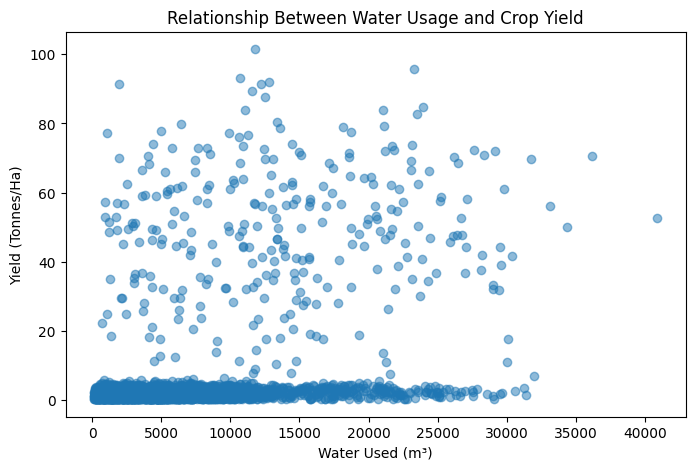

In [19]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Water_Used_m3'],
    df['Yield_Tonnes_Ha'],
    alpha=0.5
)

plt.xlabel('Water Used (m³)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.title('Relationship Between Water Usage and Crop Yield')

plt.show()

## 🌱 Question 3: Does using more water actually increase crop yield?

### Analysis

We calculated the Pearson correlation between `Water_Used_m3` and `Yield_Tonnes_Ha`.

The correlation coefficient was **0.389**, indicating a **moderate positive relationship** between water usage and crop yield.

### Key Findings

- Water usage and crop yield show a **moderate positive correlation (r = 0.389)**.
- This suggests that farms using more water generally tend to achieve higher yields.
- However, the relationship is not strong, meaning **higher water consumption does not consistently guarantee higher yield**.
- The scatter plot shows substantial variation in yield among farms with similar water consumption.
- The extremely high yields observed in some Sugarcane farms may influence the overall correlation.

### 💡 Key Insight

> **More water is associated with higher yield, but water alone does not explain crop productivity.**

Other factors such as crop type, soil conditions, fertilizer, temperature, rainfall and irrigation method may play an important role.

### ⚠️ Limitation

The overall correlation may be affected by differences between crops, particularly the much higher yield values observed for Sugarcane.

### 🎯 Next Analytical Question

> **Within each crop, does higher water usage actually lead to higher yield?**

This will help determine whether the observed relationship is genuinely related to water usage or is mainly caused by differences between crop types.

In [20]:
df.groupby('Crop')[['Water_Used_m3', 'Yield_Tonnes_Ha']].corr()

Water_Used_m3  Yield_Tonnes_Ha
Crop                                                     
Chilli    Water_Used_m3         1.000000         0.077508
          Yield_Tonnes_Ha       0.077508         1.000000
Cotton    Water_Used_m3         1.000000         0.008444
          Yield_Tonnes_Ha       0.008444         1.000000
Groundnut Water_Used_m3         1.000000        -0.058988
          Yield_Tonnes_Ha      -0.058988         1.000000
Maize     Water_Used_m3         1.000000         0.032770
          Yield_Tonnes_Ha       0.032770         1.000000
Pulses    Water_Used_m3         1.000000         0.004137
          Yield_Tonnes_Ha       0.004137         1.000000
Rice      Water_Used_m3         1.000000        -0.016751
          Yield_Tonnes_Ha      -0.016751         1.000000
Sugarcane Water_Used_m3         1.000000         0.072518
          Yield_Tonnes_Ha       0.072518         1.000000
Wheat     Water_Used_m3         1.000000         0.053439
          Yield_Tonnes_Ha       0.053439         1.000000

### Crop-Level Analysis

To investigate whether the overall relationship was consistent across crops, correlation was calculated separately for each crop.

The results showed that all crop-level correlations were very close to zero, ranging from approximately **-0.059 to 0.078**.

### 🔥 Key Discovery

> **Although overall water usage showed a moderate positive correlation with yield (r = 0.389), this relationship almost disappears when crops are analyzed individually.**

This indicates that the overall correlation is likely driven primarily by **differences between crop types**, rather than water usage having a strong relationship with yield within each crop.

For example, Sugarcane has both substantially higher yield and higher water consumption than most other crops. This contributes to the positive overall correlation.

### 💡 Final Insight

> **More water does not necessarily mean higher yield within a given crop. Crop type appears to be a much more important factor than water quantity alone.**

Therefore, simply increasing irrigation may not improve productivity. The effectiveness of water usage should instead be evaluated alongside **crop type, soil conditions, irrigation method and environmental factors**.

In [21]:
irrigation_analysis = df.groupby('Irrigation_Method').agg(
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Avg_Profit=('Profit_INR', 'mean'),
    Avg_Water_Used=('Water_Used_m3', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Avg_Disease_Risk=('Disease_Pest_Risk_pct', 'mean'),
    Farms=('Farm_ID', 'count')
).sort_values('Avg_Profit', ascending=False)

irrigation_analysis

,Avg_Yield,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency,Avg_Disease_Risk,Farms
Irrigation_Method,,,,,,
Drip,6.620662,219625.997814,5918.747541,6.267129,45.788525,915
Sprinkler,5.188819,91121.079019,6208.258856,4.669805,46.477657,734
Rainfed,4.613182,79050.365034,3549.554275,7.563784,46.494332,1041
Flood,4.897724,73354.022901,8026.472519,3.438853,46.604427,1310


Q.How does irrigation method affect crop yield, profit, water usage, water efficiency, and disease/pest risk?

Key Insights:
Drip irrigation performs the best overall — it has the highest average yield (6.62 tonnes/ha) and highest average profit (₹2,19,626).
Drip also has good water efficiency (6.27 t/1000 m³) while using 5,919 m³ of water on average, making it a strong balance between productivity and resource use.
Rainfed irrigation uses the least water (3,550 m³), but its yield (4.61 tonnes/ha) and profit (₹79,050) are much lower than Drip.
Flood irrigation uses the most water (8,026 m³) but has the lowest water efficiency (3.44 t/1000 m³) and relatively low profit (₹73,354), making it the least efficient method.
Disease/pest risk is lowest with Drip (45.79%) and highest with Flood (46.60%), although the difference is relatively small.
Overall, Drip irrigation is the most effective method, providing the best combination of high yield, high profitability, better water efficiency, and slightly lower disease/pest risk.

Q. "If a farmer wants to maximize profit while minimizing water consumption and disease risk, which irrigation method should be preferred, and why?"

In [22]:
irrigation_tradeoff = df.groupby('Irrigation_Method').agg(
    Avg_Profit=('Profit_INR', 'mean'),
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Avg_Water_Used=('Water_Used_m3', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Avg_Disease_Risk=('Disease_Pest_Risk_pct', 'mean')
)

# Normalize values so different units can be compared
irrigation_tradeoff['Profit_Score'] = (
    irrigation_tradeoff['Avg_Profit'] /
    irrigation_tradeoff['Avg_Profit'].max()
)

irrigation_tradeoff['Water_Saving_Score'] = (
    irrigation_tradeoff['Avg_Water_Used'].min() /
    irrigation_tradeoff['Avg_Water_Used']
)

irrigation_tradeoff['Disease_Safety_Score'] = (
    irrigation_tradeoff['Avg_Disease_Risk'].min() /
    irrigation_tradeoff['Avg_Disease_Risk']
)

# Overall score: higher profit + lower water + lower disease risk
irrigation_tradeoff['Overall_Score'] = (
    0.5 * irrigation_tradeoff['Profit_Score'] +
    0.3 * irrigation_tradeoff['Water_Saving_Score'] +
    0.2 * irrigation_tradeoff['Disease_Safety_Score']
)

irrigation_tradeoff.sort_values(
    'Overall_Score',
    ascending=False
)

,Avg_Profit,Avg_Yield,Avg_Water_Used,Avg_Water_Efficiency,Avg_Disease_Risk,Profit_Score,Water_Saving_Score,Disease_Safety_Score,Overall_Score
Irrigation_Method,,,,,,,,,
Drip,219625.997814,6.620662,5918.747541,6.267129,45.788525,1.000000,0.599714,1.000000,0.879914
Rainfed,79050.365034,4.613182,3549.554275,7.563784,46.494332,0.359932,1.000000,0.984819,0.676930
Sprinkler,91121.079019,5.188819,6208.258856,4.669805,46.477657,0.414892,0.571747,0.985173,0.576005
Flood,73354.022901,4.897724,8026.472519,3.438853,46.604427,0.333995,0.442231,0.982493,0.496165


In [23]:
best_method = irrigation_tradeoff['Overall_Score'].idxmax()
best_score = irrigation_tradeoff['Overall_Score'].max()

print("Best Irrigation Method:", best_method)
print("Overall Score:", round(best_score, 3))

Best Irrigation Method: Drip
Overall Score: 0.88


If a farmer wants to maximize profit while minimizing water consumption and disease risk, which irrigation method should be preferred?

Key Insights :
Drip irrigation is the best overall choice, achieving the highest overall score of 0.88.
It provides the highest average profit (₹2,19,626) and highest yield (6.62 tonnes/ha) among all irrigation methods.
Drip also has the lowest disease/pest risk (45.79%), giving it an additional advantage.
Although Rainfed uses less water, its profit and yield are considerably lower, making it less attractive when profitability is also important.
Flood irrigation should be avoided for this objective because it uses the most water (8,026 m³) while having the lowest water efficiency.
Therefore, Drip irrigation offers the best overall trade-off between profitability, productivity, water usage, and disease risk.

Final conclusion: 🌱 Drip irrigation should be preferred, with an overall score of 0.88, making it the strongest option when multiple agricultural objectives are considered together.

In [24]:
water_yield_corr = df[['Water_Used_m3', 'Yield_Tonnes_Ha']].corr()

correlation = water_yield_corr.loc[
    'Water_Used_m3',
    'Yield_Tonnes_Ha'
]

print("Water Usage vs Yield Correlation:", round(correlation, 3))

Water Usage vs Yield Correlation: 0.389


Does higher water consumption actually lead to higher crop yield?

Key Insights
The correlation is 0.389, indicating a moderate positive relationship between water usage and crop yield.
This suggests that higher water usage is generally associated with higher yield in your dataset.
However, the relationship is not strong enough to conclude that water usage alone determines yield.
Other factors such as irrigation method, crop type, soil conditions, weather, fertilizer use, and disease/pest risk may also influence yield.
Therefore, increasing water can contribute to higher yield, but simply using more water is not necessarily the most efficient strategy.

🔥 Strong conclusion:

Water availability matters, but efficient irrigation matters more — the moderate correlation (0.389) suggests that higher water use can improve yield, but it is not the only driver of productivity

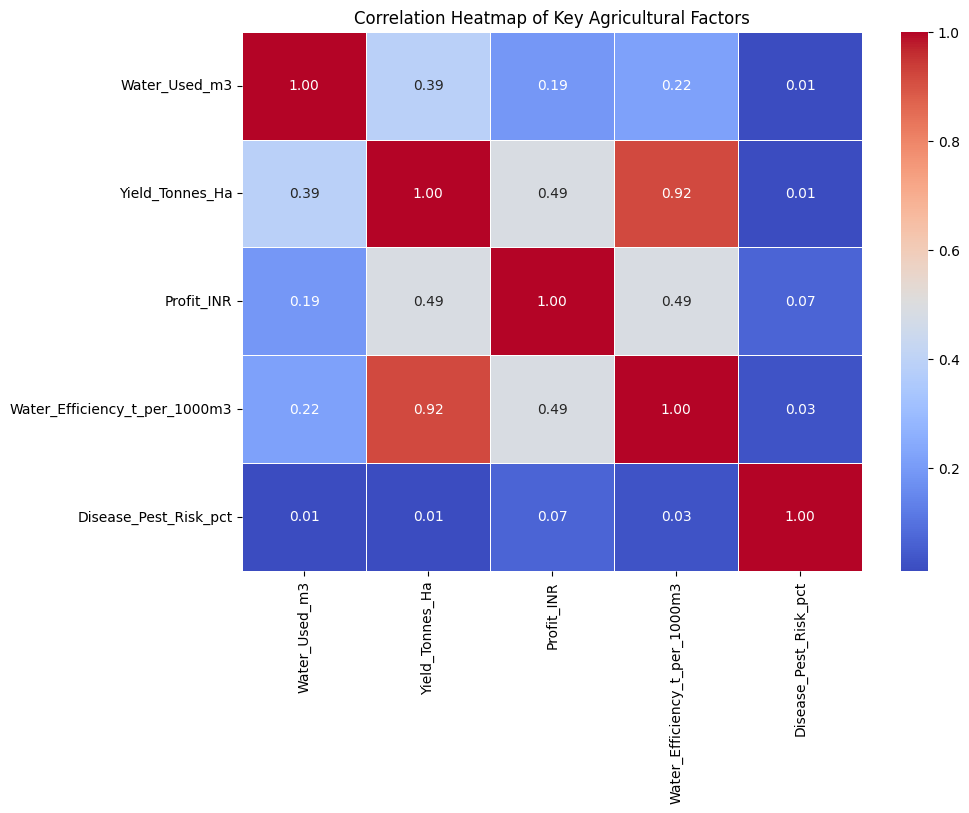

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select important numerical variables
corr_data = df[
    [
        'Water_Used_m3',
        'Yield_Tonnes_Ha',
        'Profit_INR',
        'Water_Efficiency_t_per_1000m3',
        'Disease_Pest_Risk_pct'
    ]
]

# Calculate correlation matrix
correlation_matrix = corr_data.corr()

# Plot heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Key Agricultural Factors')
plt.show()

How are agricultural performance, resource usage, and economic outcomes related across different seasons?

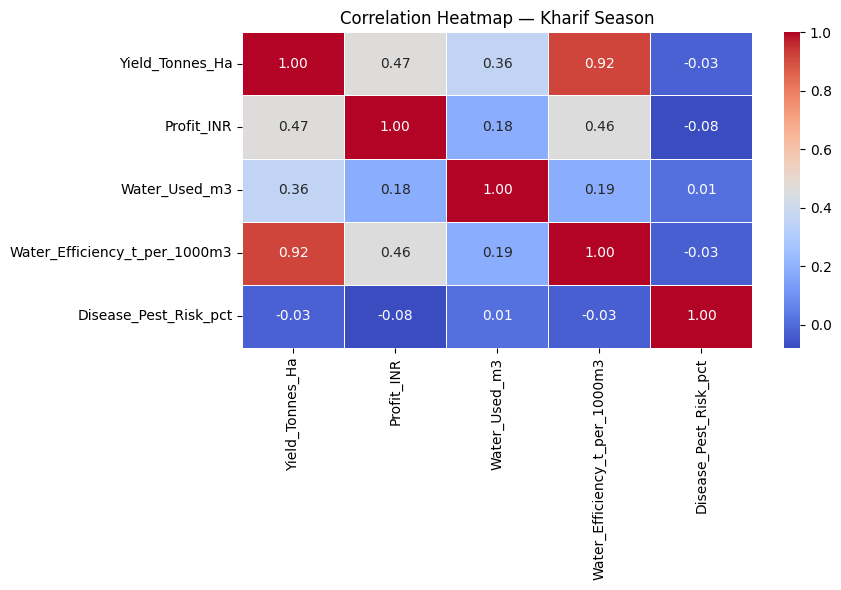

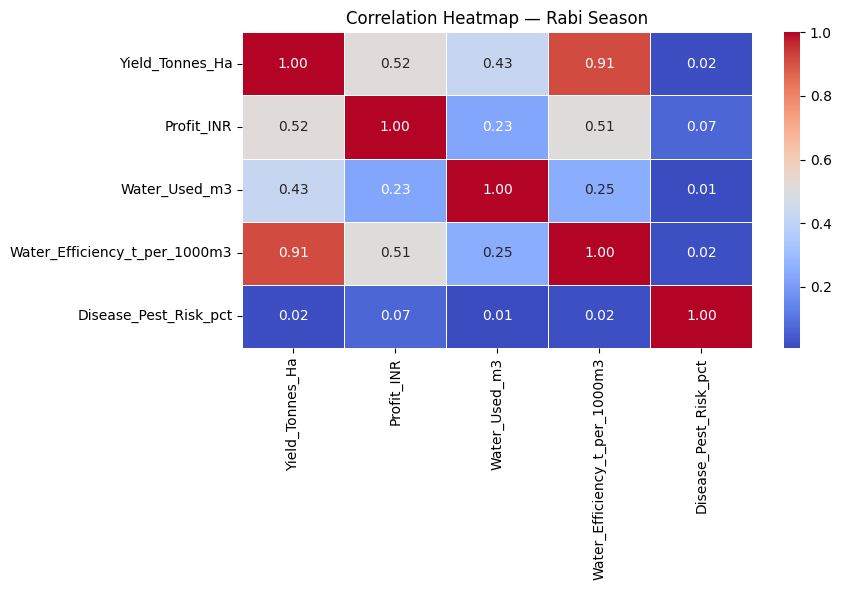

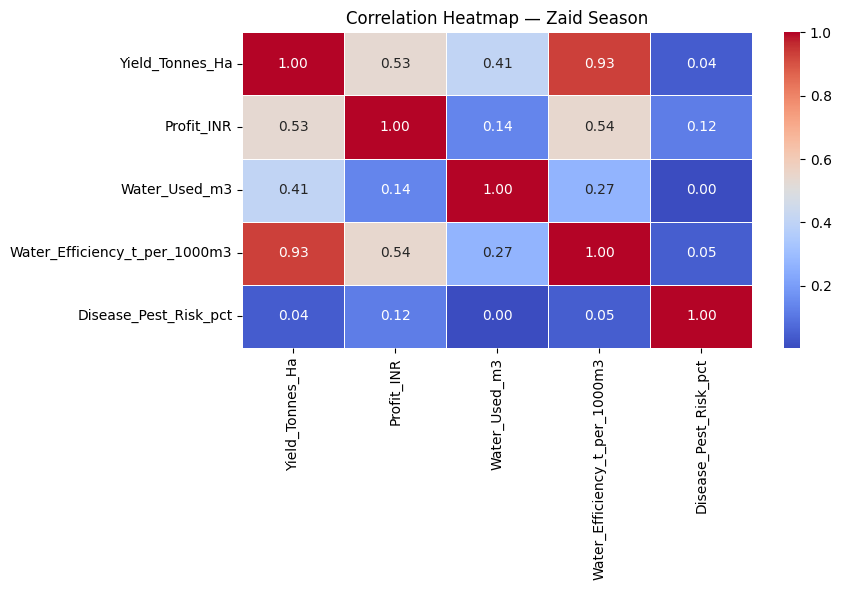

In [27]:
seasons = df['Season'].unique()

for season in seasons:
    seasonal_data = df[df['Season'] == season][
        [
            'Yield_Tonnes_Ha',
            'Profit_INR',
            'Water_Used_m3',
            'Water_Efficiency_t_per_1000m3',
            'Disease_Pest_Risk_pct'
        ]
    ]

    correlation_matrix = seasonal_data.corr()

    plt.figure(figsize=(9, 6))

    sns.heatmap(
        correlation_matrix,
        annot=True,
        cmap='coolwarm',
        fmt='.2f',
        linewidths=0.5
    )

    plt.title(f'Correlation Heatmap — {season} Season')
    plt.tight_layout()
    plt.show()

Based on seasonal performance, resource usage, and economic outcomes, what agricultural strategy should be recommended for better seasonal planning?

In [28]:
# Analyze overall performance by season

seasonal_strategy = df.groupby('Season').agg(
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Avg_Profit=('Profit_INR', 'mean'),
    Avg_Water_Used=('Water_Used_m3', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Avg_Disease_Risk=('Disease_Pest_Risk_pct', 'mean'),
    Farms=('Farm_ID', 'count')
)

# Normalize indicators
seasonal_strategy['Yield_Score'] = (
    seasonal_strategy['Avg_Yield'] /
    seasonal_strategy['Avg_Yield'].max()
)

seasonal_strategy['Profit_Score'] = (
    seasonal_strategy['Avg_Profit'] /
    seasonal_strategy['Avg_Profit'].max()
)

seasonal_strategy['Water_Efficiency_Score'] = (
    seasonal_strategy['Avg_Water_Efficiency'] /
    seasonal_strategy['Avg_Water_Efficiency'].max()
)

# Lower water usage and disease risk are better
seasonal_strategy['Water_Saving_Score'] = (
    seasonal_strategy['Avg_Water_Used'].min() /
    seasonal_strategy['Avg_Water_Used']
)

seasonal_strategy['Disease_Safety_Score'] = (
    seasonal_strategy['Avg_Disease_Risk'].min() /
    seasonal_strategy['Avg_Disease_Risk']
)

# Overall seasonal planning score
seasonal_strategy['Overall_Score'] = (
    0.30 * seasonal_strategy['Yield_Score'] +
    0.30 * seasonal_strategy['Profit_Score'] +
    0.20 * seasonal_strategy['Water_Efficiency_Score'] +
    0.10 * seasonal_strategy['Water_Saving_Score'] +
    0.10 * seasonal_strategy['Disease_Safety_Score']
)

# Rank seasons
seasonal_strategy = seasonal_strategy.sort_values(
    'Overall_Score',
    ascending=False
)

seasonal_strategy

,Avg_Yield,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency,Avg_Disease_Risk,Farms,Yield_Score,Profit_Score,Water_Efficiency_Score,Water_Saving_Score,Disease_Safety_Score,Overall_Score
Season,,,,,,,,,,,,
Kharif,5.643973,178914.647555,6102.201237,5.891834,54.467903,1779,1.000000,1.000000,1.000000,0.958177,0.701636,0.965981
Rabi,5.080498,87689.470191,5846.987093,5.186122,40.482114,1627,0.900163,0.490119,0.880222,1.000000,0.944038,0.787533
Zaid,4.665942,-24804.824916,6419.893939,4.413239,38.216667,594,0.826712,-0.138641,0.749043,0.910761,1.000000,0.547306


Key Insights
Kharif is the strongest-performing season overall, with the highest yield (5.64 tonnes/ha) and average profit (₹1.79 lakh).
Kharif also records the highest water efficiency (5.89 t/1000 m³), making it the most productive and economically favorable season despite relatively high water usage.
Rabi provides a balanced alternative — it uses the least water (5,847 m³) and has considerably lower disease/pest risk (40.48%) than Kharif, while still maintaining good yield.
Zaid is the weakest season economically, with an average loss of ₹24,805 and the lowest yield (4.67 tonnes/ha).
Zaid also has the lowest water efficiency (4.41 t/1000 m³), meaning its relatively high water consumption (6,420 m³) does not translate into proportionally high productivity.
The Overall Score confirms the ranking: Kharif (0.966) > Rabi (0.788) > Zaid (0.547).
Strategic recommendation: Prioritize major agricultural production during Kharif, use Rabi for efficient and lower-risk cultivation, and adopt cost control, crop selection, and water-efficient practices in Zaid to reduce the likelihood of losses.
🔥 Final takeaway

Kharif should be the priority season for maximizing agricultural returns, while Rabi offers a more resource-efficient and lower-risk option. Zaid requires targeted interventions to improve profitability and resource efficiency.

1. Data Quality & Preprocessing
✅ Checked dataset structure, data types, and basic statistics.
✅ Checked for null/missing values and handled them appropriately.
✅ Checked for duplicate records.
✅ Prepared numerical and categorical variables for analysis.
✅ Verified the data before performing statistical analysis.
2. Univariate Analysis
✅ Analyzed individual variables such as Yield, Profit, Water Usage, Water Efficiency, and Disease/Pest Risk.
✅ Examined distributions and variations in important agricultural indicators.
✅ Identified major ranges and unusual values in the dataset.
3. Multivariate Analysis
✅ Compared multiple agricultural factors simultaneously.
✅ Analyzed the relationship between irrigation method, yield, profit, water usage, efficiency, and disease risk.
✅ Drip irrigation showed the strongest overall performance.
✅ Drip achieved the highest average yield (6.62 tonnes/ha) and profit (~₹2.20 lakh).
✅ Flood irrigation used the most water (~8,026 m³) but had the lowest water efficiency.
✅ Rainfed used the least water (~3,550 m³), but produced lower yield and profit.
4. Correlation Analysis
✅ Performed correlation analysis between major numerical variables.
✅ Water Usage vs Yield correlation = 0.389, indicating a moderate positive relationship.
✅ This suggests that higher water usage is generally associated with higher yield, but water usage alone does not determine productivity.
✅ Correlation analysis helped identify relationships that require consideration alongside other agricultural factors.
5. Seasonal Analysis
✅ Compared Kharif, Rabi, and Zaid seasons.
✅ Kharif had the highest yield (5.64 tonnes/ha) and profit (~₹1.79 lakh).
✅ Rabi used the least water among the three seasons (~5,847 m³) and had relatively low disease/pest risk.
✅ Zaid had the lowest economic performance, with an average loss of ~₹24,805.
✅ Zaid also had the lowest water efficiency (4.41 t/1000 m³).
✅ Overall seasonal score: Kharif (0.966) > Rabi (0.788) > Zaid (0.547).
✅ Seasonal analysis revealed clear differences in productivity, resource usage, and profitability.
6. Evidence-Based Insights
✅ All major conclusions are supported by calculated averages, correlations, and comparison scores.
✅ Drip irrigation provides the strongest combination of yield, profit, water efficiency, and disease-risk performance.
✅ Kharif is the strongest season for overall agricultural returns.
✅ More water does not automatically guarantee proportionally higher productivity.
✅ Resource-efficient practices are important for improving agricultural sustainability.
7. Recommendations
🌱 Prioritize Drip irrigation where feasible because of its high productivity and profitability.
💧 Promote water-efficient irrigation practices instead of simply increasing water consumption.
📈 Prioritize major production during Kharif based on its strong economic performance.
🌾 Use Rabi as a comparatively resource-efficient cultivation period.
⚠️ Apply targeted cost control, crop selection, and resource management in Zaid to reduce losses.
📊 Use seasonal and irrigation-level data to support future agricultural planning.
8. Limitations
⚠️ Correlation indicates association, not causation.
⚠️ The analysis does not prove that irrigation method alone causes differences in yield or profit.
⚠️ Other factors such as crop type, soil conditions, weather, fertilizer usage, farm size, and location may influence outcomes.
⚠️ Average values can hide variations between individual farms.
⚠️ The weighted Overall Score depends on selected weights and therefore represents an analytical decision framework rather than an absolute measure.
9. Overall Conclusion
🌾 Agricultural performance varies considerably across irrigation methods and seasons.
💧 Efficient resource utilization is an important factor alongside yield and profitability.
🌱 Drip irrigation emerged as the strongest irrigation option in the analyzed dataset.
☀️ Kharif emerged as the strongest season overall.
📊 Combining seasonal, economic, resource, and correlation analyses provides a more comprehensive basis for agricultural decision-making.
🎯 The findings can support evidence-based seasonal planning, irrigation selection, and resource management.